<a href="https://colab.research.google.com/github/elzbietapiechota/neural-network-dense/blob/main/NN_Classification_iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, f1_score
from sklearn.preprocessing import label_binarize

metrics_list = []
models = []
models_names = []
predictions_proba_list = []

def calculate_metrics_keras(model, name, X_checked, y_checked):
    models.append(model)
    models_names.append(name)

    predictions_proba = model.predict(X_checked)
    predictions_proba_list.append(predictions_proba)

    # Wyciągamy indeksy oznaczające konkretne klasy (0, 1, 2) przy użyciu argmax
    predictions = np.argmax(predictions_proba, axis=1)

    species_names = ['Setosa', 'Versicolor', 'Virginica'] # Prawdziwe nazwy kwiatów z Iris

    ############## metryki dla sprawdzanego modelu ################
    # Precision, Recall, F1, Accuracy
    print(f"Model: {name}")
    print(classification_report(y_checked, predictions, target_names=species_names))

    # Confusion matrix
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(y_checked, predictions)
    ax = sns.heatmap(cm, annot=True, cmap='Blues', fmt='.0f',
                     xticklabels=species_names, yticklabels=species_names)
    ax.set_title(f'Confusion Matrix - {name}\n\n')
    ax.set_xlabel('\nPredicted Values')
    ax.set_ylabel('Actual Values')
    plt.show()

    # plot ROC curve
    y_checked_bin = label_binarize(y_checked, classes=[0, 1, 2])

    fig = plt.figure(figsize=(7, 7))
    plt.plot([0, 1], [0, 1], 'k--')
    for model_selected, name_selected, pred_proba in zip(models, models_names, predictions_proba_list):
        fpr_grid = np.linspace(0, 1, 100)
        tpr_list = []
        for i in range(3):
            fpr_c, tpr_c, _ = roc_curve(y_checked_bin[:, i], pred_proba[:, i])
            tpr_list.append(np.interp(fpr_grid, fpr_c, tpr_c))

        mean_tpr = np.mean(tpr_list, axis=0)
        mean_auc = roc_auc_score(y_checked, pred_proba, multi_class='ovr', average='macro')

        plt.plot(fpr_grid, mean_tpr, label=f'{name_selected} (AUC = {mean_auc:.4f})')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

    f1_metric = f1_score(y_checked, predictions, average='macro')
    auc_metric = roc_auc_score(y_checked, predictions_proba, multi_class='ovr', average='macro')

    if not any(d['Model'] == name for d in metrics_list):
        metrics_list.append({'Model': name, 'F1_score': f1_metric, 'AUC': auc_metric})

    return pd.DataFrame(metrics_list)

In [ ]:
# wczytanie danych
url = "https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv"
df = pd.read_csv(url)
df

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [ ]:
# sprawdzenie danych
df.info()
print()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB



,sepal.length,sepal.width,petal.length,petal.width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
# wektoryzacja targetu na liczby 0-2
df['variety'] = df['variety'].astype('category').cat.codes

In [ ]:
# preprocessing
X = df.drop(columns=['variety']).values
y = df['variety'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# deklarowanie modelu
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dense(12, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')])

# kompilacja modelu
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy'])

# wartości warstw modelu
model.summary()

# określenie mechanizmu EarlyStopping w czasie treningu modelu
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True)

# trening modelu
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=8,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           204 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            39 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 323 (1.26 KB)

 Trainable params: 323 (1.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.3667 - loss: 1.2132 - val_accuracy: 0.5333 - val_loss: 1.1990
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5833 - loss: 1.1209 - val_accuracy: 0.6000 - val_loss: 1.1094
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6417 - loss: 1.0433 - val_accuracy: 0.6000 - val_loss: 1.0323
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6583 - loss: 0.9736 - val_accuracy: 0.6000 - val_loss: 0.9570
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6667 - loss: 0.9032 - val_accuracy: 0.6000 - val_loss: 0.8854
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6250 - loss: 0.8361 - val_accuracy: 0.5333 - val_loss: 0.8185
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5833 - loss: 0.7721 - val_accuracy: 0.5333 - val_loss: 0.7540
Epoch 8/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6333 - loss: 0.7144 - val_accuracy: 0.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Model: Neural Network
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



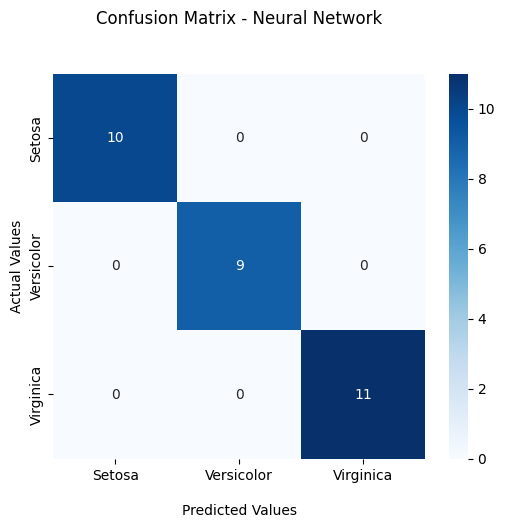

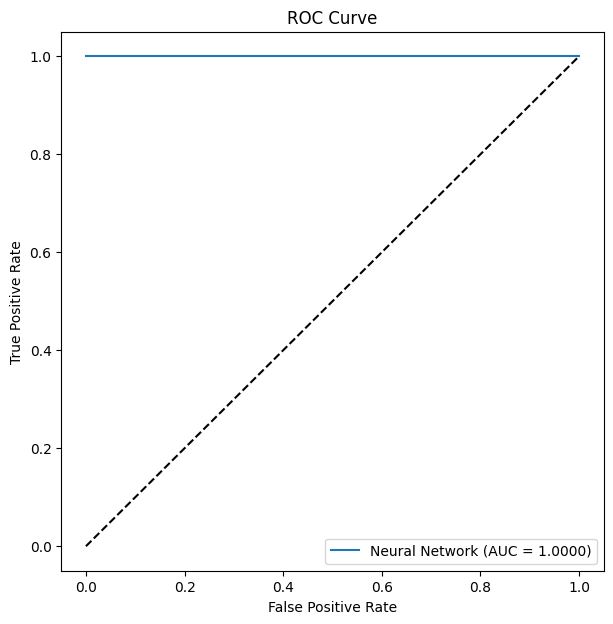

,Model,F1_score,AUC
0,Neural Network,1.0,1.0


In [ ]:
# metryki sieci neuronowej
df_metrics = calculate_metrics_keras(model, "Neural Network", X_test, y_test)
df_metrics